In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
import numpy as np
import glob
import os


In [2]:
model = load_model('cnn_model.h5')
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 478, 478, 32)      896       
                                                                 
 batch_normalization_3 (Bat  (None, 478, 478, 32)      128       
 chNormalization)                                                
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 239, 239, 32)      0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 237, 237, 64)      18496     
                                                                 
 batch_normalization_4 (Bat  (None, 237, 237, 64)      256       
 chNormalization)                                                
                                                      

In [3]:
img_size= (480,480)

def preprocess_image(image_path):
    img = load_img(image_path,target_size = img_size)
    img_array = img_to_array(img) /255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array

test_dir = '/Users/d.k./Desktop/Dogs_cats_recog/dogs-vs-cats/test1'
test_img = glob.glob(os.path.join(test_dir,'*.jpg'))


In [4]:
prediction = []
confidence = []

for img_path in test_img:
    processed_img = preprocess_image(img_path)
    pred = model.predict(processed_img, verbose=0)[0]
    prediction.append('Dog' if pred>0.5 else 'Cat')
    confidence.append(float(pred))
    
print('Predictions complete')


    

/var/folders/d6/zv5wx11j1bjcmg46xbyj0jb40000gn/T/ipykernel_63739/2895265598.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  confidence.append(float(pred))


KeyboardInterrupt: 

In [ ]:
plt.figure(figsize=(15,10))
for i, (img_path,pred,conf) in enumerate(zip(test_img, prediction, confidence)):
    plt.subplots(3,4)
    img = load_img(img_path, target_size=(480,480))
    plt.imshow(img)
    plt.title(f'{pred} confidenc : {conf:.2%}')
    plt.axis('off')
plt.suptitle('Model prediction on test images')
plt.tight_layout()
plt.show()

/var/folders/d6/zv5wx11j1bjcmg46xbyj0jb40000gn/T/ipykernel_33041/2062199159.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.subplots(3,4)


KeyboardInterrupt: 

1/1 [==============================] - 0s 26ms/step
0.9781849


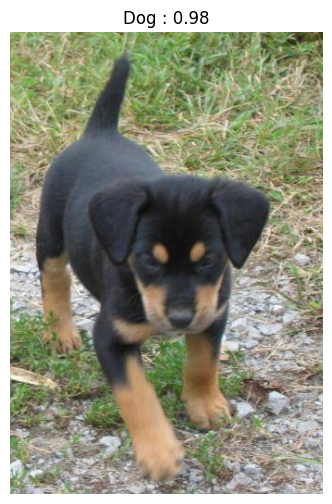

In [6]:
single_img_path = 'dogs-vs-cats/test1/1216.jpg'
process = preprocess_image(single_img_path)
pred = model.predict(process)[0][0]
print(pred)
label = 'Dog' if pred>0.50 else 'Cat'
confidence = pred if pred>0.50 else 1- pred

plt.figure(figsize=(6,6))
img = load_img(single_img_path)
plt.imshow(img)
plt.title(f'{label} : {confidence:.2f}')
plt.axis('off')
plt.show()